0310(월) 2주차 과제\
핸즈온 7장 앙상블 학습과 랜덤 포레스트 p.245-257

**앙상블**
- 일련의 예측기
- 예: 훈련 세트로부터 무작위로 각기 다른 서브셋을 만들어 일련의 결정 트리 분류기 훈련, 모든 개별 트리의 예측을 구한 후 가장 많은 선택을 받은 클래스 선택(**랜덤 포레스트**)
- 외에도 **배깅, 부스팅, 스태킹** 등 다양한 앙상블 방법 존재



# 7.1 투표 기반 분류기

In [2]:
import warnings
warnings.filterwarnings('ignore')

# 데이터셋 불러오기

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X,y = make_moons(n_samples=100, noise=0.15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [3]:
# 여러 분류기 조합하여 VotingClassifier를 만들고 훈련시키는 코드

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='hard')
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()), ('svc', SVC())])

In [4]:
from sklearn.metrics import accuracy_score

for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.8
RandomForestClassifier 0.95
SVC 1.0
VotingClassifier 1.0


-> 투표 기반 분류기가 다른 개별 분류기보다 성능이 높음

**간접 투표(soft voting)**
- 개별 분류기의 예측을 평균내어 확률이 가장 큰 클래스를 예측함.
- 확률이 높은 투표에 비중을 더 두기 때문에 직접 투표 방식보다 성능이 높음.

**간접 투표 사용 조건 및 방법**
- 모든 분류기가 클래스의 확률을 예측할 수 있어야 함. 즉, predict_proba() 메서드가 있어야 함
- voting="hard" 를 voting="soft" 로 바꿔야 함
- SVC는 기본값에서는 클래스 확률을 제공하지 않으므로 probability 매개변수를 True로 지정해야 함

# 7.2 배깅과 페이스팅

**다양한 분류기를 만드는 방법**
- 각기 다른 훈련 알고리즘을 사용하기
- 같은 알고리즘을 사용하고 훈련 세트의 서브셋을 무작위로 구성해 분류기를 각각 다르게 학습시키기

**샘플링 방식**
- **배깅**: 훈련 세트에서 중복을 허용하여 샘플링하는 방식
- **페이스팅**: 중복을 허용하지 않고 샘플링하는 방식

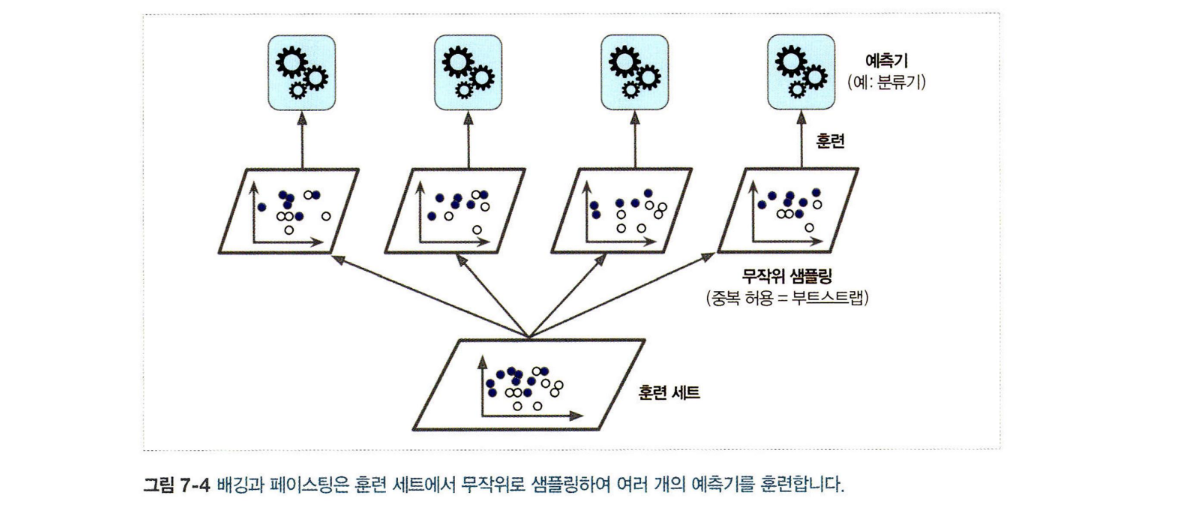

    - 모든 예측기가 훈련을 마치면 앙상블은 모든 예측을 모아 새로운 예측을 만듦
    - 분류: 통계적 최빈값 계산
    - 회귀: 평균 계산

- 개별 예측기: 원본 훈련 세트로 훈련시킨 것보다 훨씬 편향되어있음
- 수집 함수 통과 후: 편향 감소, 분산 감소
- 앙상블의 결과: 원본에 비해 편향은 비슷, 분산은 감소

## 7.2.1 사이킷런의 배깅과 페이스팅

사이킷런은 배깅과 페이스팅을 위해 **BaggingClassifier, BaggingRegressor** 를 제공함

**아래 코드에서 매개변수**
- bootstrap
    - True: 배깅
    - False: 페이스팅
- n_jobs: 훈련과 예측에 사용할 CPU 코어 수 지정
    - -1로 지정 시 가용한 모든 코어 사용

In [6]:
# 결정 트리 분류기 500개의 앙상블을 훈련시키는 코드

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    max_samples=50, bootstrap=True, n_jobs=-1
)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

**NOTE**
- BaggingClassifier는 기반이 되는 분류기가 결정 트리 분류기처럼 클래스 확률을 추정할 수 있으면(즉, predict_proba() 함수가 있으면) 자동으로 직접 투표 대신 **간접 투표 방식**을 사용함.

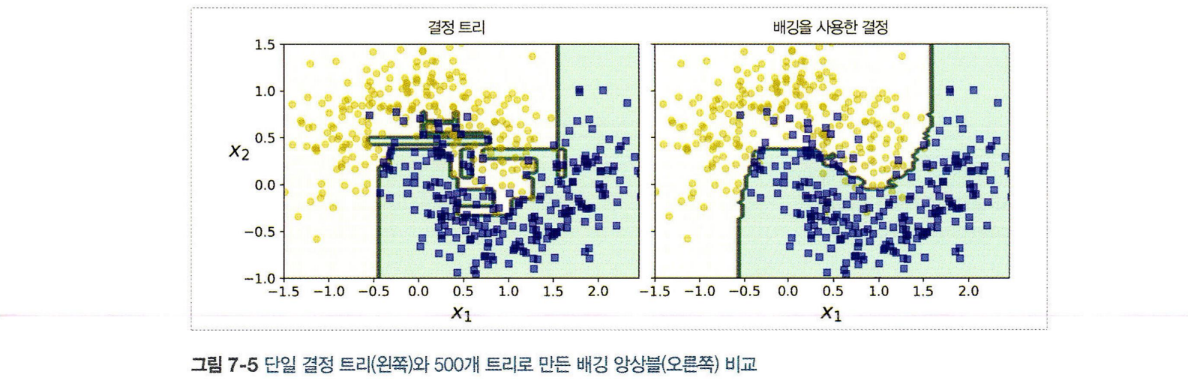

    - 앙상블의 예측이 결정 트리 하나의 예측보다 일반화가 잘된 것 같음

**배깅과 페이스팅의 선택**
- 부트스트래핑(중복 허용)은 서브셋에 다양성을 증가시킴 $->$ 배깅이 페이스팅보다 편향이 조금 더 높음(중복되니까)
- But 다양성을 추가 $->$ 예측기들의 상관관계를 줄임 $->$ 앙상블의 분산을 감소시킴
- 전반적으로 배깅이 더 좋은 모델을 만드어서 더 선호하지만, 시간과 CPU에 여유가 있으면 교차 검증으로 둘 다 해보고 더 나은 쪽 선택할 것

## 7.2.2 oob 평가

**배깅의 단점**
- 어떤 샘플은 여러번 샘플링되고, 어떤 것은 전혀 선택되지 않을 수 있음
- BaggingClassifier는 기본값으로 중복을 허용하여 훈련 세트의 크기만큼인 m개 샘플을 선택함
- 이는 평균적으로 각 예측기에 훈련 샘플의 63%정도만 샘플링된다는 것을 의미함

**obb 샘플**
- 선택되지 않은 훈련 샘플의 나머지 37%
- 예측기마다 남겨진 37%는 모두 다름
- obb 평가: obb 샘플을 사용한 평가
- 각 예측기의 obb 평가를 평균하여 앙상블의 평가를 얻을 수 있음

In [7]:
# obb_score 매개변수로 obb 평가 자동 수행

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    bootstrap=True, n_jobs=-1, oob_score=True)

bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.925

$->$ 약 92.5%의 정확도를 얻을 것으로 보임

In [8]:
# 정확도 확인

from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

$->$ 100%의 정확도를 확인함

In [10]:
# oob_decision_function_ 변수로 oob 샘플에 대한 결정 함수 값 확인

bag_clf.oob_decision_function_

array([[0.41758242, 0.58241758],
       [0.13333333, 0.86666667],
       [0.28742515, 0.71257485],
       [1.        , 0.        ],
       [0.98265896, 0.01734104],
       [0.01041667, 0.98958333],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.11      , 0.89      ],
       [0.085     , 0.915     ],
       [1.        , 0.        ],
       [0.09302326, 0.90697674],
       [0.01075269, 0.98924731],
       [0.26020408, 0.73979592],
       [1.        , 0.        ],
       [0.17222222, 0.82777778],
       [0.        , 1.        ],
       [0.02427184, 0.97572816],
       [0.3021978 , 0.6978022 ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.29032258, 0.70967742],
       [0.52046784, 0.47953216],
       [0.86734694, 0.13265306],
       [0.18681319, 0.81318681],
       [0.99473684, 0.00526316],
       [0.79591837, 0.20408163],
       [0.

$->$ 첫번째 훈련 샘플이 양성 클래스에 속할 확률은 58.24%로 추측

# 7.3 랜덤 패치와 랜덤 서브스페이스

**특성 샘플링**
- BaggingClassifier는 특성 샘플링도 지원함
- max_features, bootstrap_features 두 매개변수로 조절됨
- 이미지와 같은 고차원의 데이터셋을 다룰 때 유용함
- 더 다양한 예측기를 만들며 편향을 늘리는 대신 분산을 낮춤

**랜덤 패치 방식**
- 훈련 특성과 샘플을 모두 샘플링하는 것

**랜덤 서브스페이스 방식**
- 훈련 샘플은 모두 사용, 특성만 샘플링하는 것
- **bootstrap=False** & **max_samples=1.0** 설정(훈련 샘플 모두 사용)
- **bootstrap_features=True** & or **max_features < 1.0**

# 7.4 랜덤 포레스트

**랜덤 포레스트**
- 배깅 혹은 페이스팅을 적용한 결정 트리의 앙상블
- 매개변수 **max_samples**: 훈련 세트의 크기로 지정
- BaggingClassifier에 DecisionTreeClassifier를 넣어 만드는 대신
- **RandomForestClassifier** 사용 가능

In [13]:
# 500개 트리로 이루어진 랜덤 포레스트 분류기를 여러 CPU 코어에서 훈련
# RandomForestClassifier로 생성

from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1)
rnd_clf.fit(X_train, y_train)

y_pred_rf = rnd_clf.predict(X_test)

In [14]:
# BaggingClassifier로 생성

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="auto", max_leaf_nodes=16),
    n_estimators=500, max_samples=1.0, bootstrap=True, n_jobs=-1)

## 7.4.1 엑스트라 트리

랜덤 포레스트에서 트리를 만들 때 각 노드는 무작위로 서브셋을 만들어 분할에 사용함 & **트리를 무작위로 만들기 위해** 최적의 임곗값을 찾는 대신 **후보 특성을 사용해 무작위로 분할한 다음, 그중에서 최상의 분할을 찾음**

**익스트림 랜덤 트리 앙상블(엑스트라 트리)**
- 편향이 늘어나지만 분산을 낮춤
- 모든 노드에서 특성마다 최적의 임곗값을 찾을 필요가 없음 $->$ 일반적인 랜덤 포레스트보다 훨씬 빠름

**TIP**
- RandomForestClassifier가 ExtraTreesClassifier 보다 더 나을지는 모름.
- 둘 다 시도해보고 교차 검증으로 비교해볼 것
- 그 후 그리드 탐색으로 하이퍼파라미터 튜닝

## 7.4.2 특성 중요도

**랜덤 포레스트의 장점**
- 특성의 상대적 중요도를 측정하기 쉬움

**사이킷런의 특성 중요도 측정**
- 어떤 특성을 사용한 노드가 평균적으로 불순도를 얼마나 감소시키는지 확인 (가중치 평균)
- 훈련이 끝난 뒤 특성마다 이 점수를 계산하고 중요도의 합이 1이 되도록 결괏값을 정규화함
- 이 값은 feature_importances_ 변수에 저장됨

In [15]:
# iris 데이터셋에 RandomForestClassifier를 훈련, 각 특성의 중요도 출력

from sklearn.datasets import load_iris
iris = load_iris()
rnd_clf = RandomForestClassifier(n_estimators=500, n_jobs=-1)
rnd_clf.fit(iris["data"], iris["target"])
for name, score in zip(iris["feature_names"], rnd_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.09468819271921201
sepal width (cm) 0.023881579018416362
petal length (cm) 0.4600161889607551
petal width (cm) 0.4214140393016164


$->$ 꽃잎의 길이(46%), 너비(42%)가 중요해보임
$->$ 꽃받침의 길이(9%), 너비(2%)가 덜 중요해보임

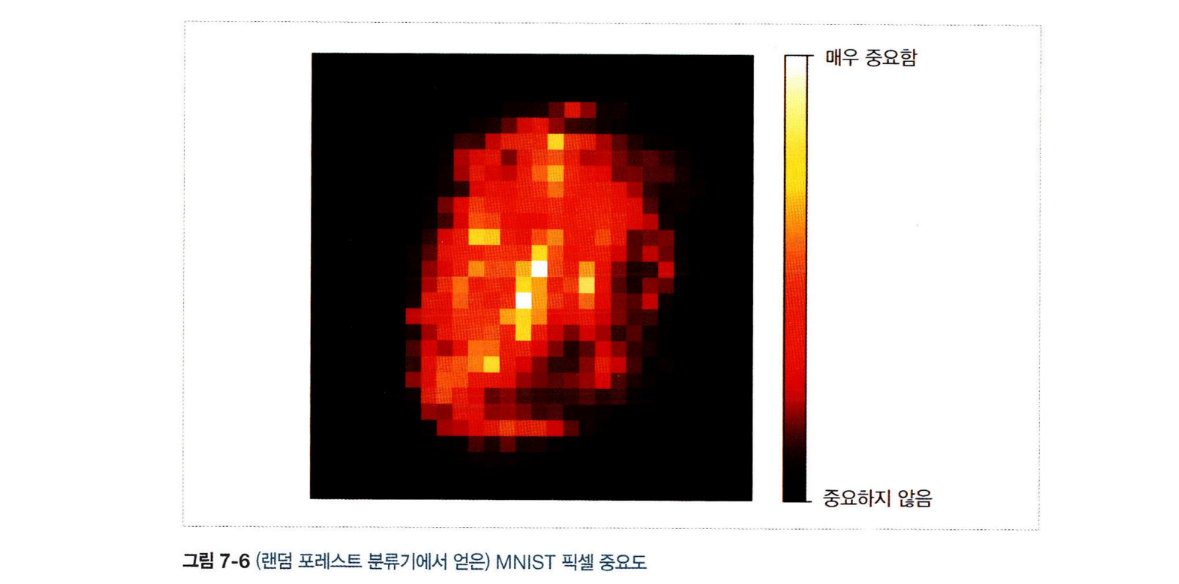

    - 3장의 MNIST 데이터셋에 랜덤 포레스트 분류기를 훈련시키고 각 픽셀의 중요도를 나타내면 위와 같은 이미지를 얻을 수 있음